In [193]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sp
from IPython.display import HTML

# **Part 1: The Wave Equation**
We solve the wave equation
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x)
$$
with periodic boundary conditions
$$
u(-L) = u(L).
$$



### Question 1
Implement the finite difference scheme above for the wave equation with periodic boundary conditions.

In [194]:
def solve_wave_equation():
  #Initializing variables
  L = 10
  a = -L
  b = L
  c = 1
  K = 12
  M = 2**K
  h = (b - a)/M
  T = L/2*c
  N = 1100
  tau = T / N
  t = 5
  u_0 = lambda x: np.exp(-(x**2))
  v_0 = lambda x: 2 * c * x * np.exp(-(x**2))
  f = lambda x,t: 0

  xs = [a + i * h for i in range(M + 1)]
  ts = [n * tau for n in range(N + 1)]

  #U[i,n] approximates u(x_i, t_n)
  U = np.zeros((M + 1, N + 1))

  #Initialize t_0
  for i in range(1, M):
      U[i, 0] = u_0(xs[i])
  U[0, 0] = u_0(xs[0])
  U[M, 0] = U[0,0]

  #Initialize t_1
  for i in range(1, M):
      U[i, 1] = U[i,0] + tau * v_0(xs[i])
  U[0, 1] = U[0,0] + tau * v_0(xs[0]) + ((c**2 * tau**2)/h**2) * (U[1,0]-2*U[0,0]+U[M-1,0]) + (tau**2)/2 * f(xs[i],ts[0])
  U[M, 1] = U[0,1]

  #Explicit timestepping
  for n in range(1, N):
      for i in range(1, M):
          U[i, n + 1] = (
              2 * U[i,n] - U[i,n-1] + ((c**2 * tau**2) / (h**2)) * (U[i+1,n] - 2 * U[i,n] + U[i-1,n]) + f(xs[i],ts[n])
          )
  U[0, n + 1] = 2*U[0,n]-U[0,n-1]+((c**2*tau**2)/(h**2))*(U[1,n]-2*U[0,n]+U[M-1,n]) + (tau**2)*f(xs[0],ts[n])
  U[M, n + 1] = U[0, n+1]
  

  return U

### Question 2
Test your code with the method of manufactured solutions.

Let $L = 10$, $c = 1$, $u(t,x) = \exp(-(x-ct)^2)$.
Compute the corresponding $f$, $u^0$, and $v^0$ such that $u$ solves the PDE.
Run until final time $T := L/(2c) = N\tau$.
        
Plot $U_i^N$ versus $u(t_N,x_i)$ at the grid points $x_i$ for the highest refinement level.

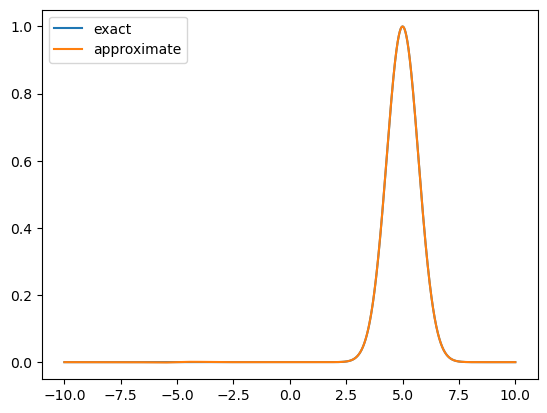

In [195]:
def u_exact(x, c, t):
    return np.exp(-(x-c*t)**2)

def test_wave_equation():
    L = 10
    K = 12
    M = 2**K
    N = 1100
    a = -L
    b = L
    c = 1
    t = 5

    # exact solution at the discrete grid points
    h = (b - a) / (M)
    xs = [a + i * h for i in range(M + 1)]
    U_exact = [u_exact(x, c, t) for x in xs]


    # approximate solution
    U_approx = solve_wave_equation()

    # plot solutions
    plt.plot(xs, U_exact, label="exact")
    plt.plot(xs, U_approx[:,-1], label="approximate")
    plt.legend()
    plt.show()


test_wave_equation()


### Question 3
Let
	      \begin{equation}
		      e_k := \max_{0\leq i \leq M} |U_i^N - u(t_N,x_i)|
	      \end{equation}
	      denote the discrete error at the final time for mesh refinement level $k$, where we recall that $M = 2^k$.
	      Create a log--log plot of $e_k$ versus the mesh size $h_k := 2L/M = L / 2^{k-1}$ for $k = 10,11,12$.

h		E_M
1.953125e-02	1.000594e+00
9.765625e-03	9.999890e-01
4.882812e-03	9.770214e-04


/var/folders/yq/j6njbwkj4f57v6y1zqqpmb4r0000gn/T/ipykernel_25351/78098213.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


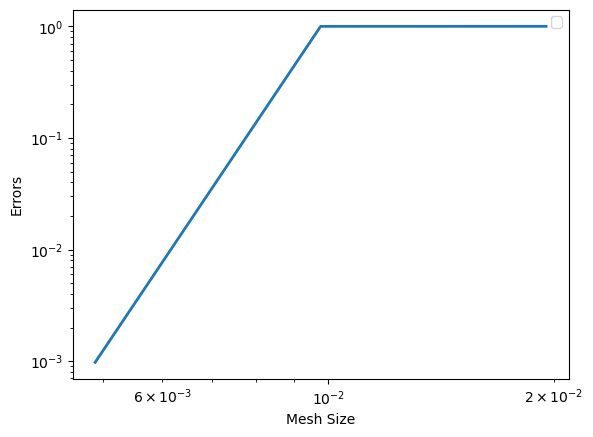

In [ ]:
def compute_errors(k_s):
    c = 1
    t = 5
    L = 10
    a = -L
    b = L
    K = 12
    M = 2**K
    h_list = []
    e_list = []

    #Table headers
    print("h\t\tE_M")

    for k in k_s:
        M = 2**k
        U = solve_wave_equation()
        h = (b - a)/M

        xs = [a + i * h for i in range(M + 1)]
        U_exact = [u_exact(x, c, t) for x in xs]

        E_M = max([abs(U_exact[i] - U[i,-1]) for i in range(M + 1)])
        h_list.append(h)
        e_list.append(E_M)

        # table entry
        print("{:e}\t{:e}".format(h, E_M))

    #Plot
    plt.loglog(h_list, e_list, linestyle='-', linewidth = 2)
    plt.xlabel("Mesh Size")
    plt.ylabel("Errors")
    plt.legend()    
    plt.show()


compute_errors([10,11,12])


### Question 4
Make an animation of your approximate solution $U_i^n$.

### Question 5
Now set $f(t,x) = 0$ and $v^0 = 0$.
	      Experiment with different periodic initial conditions $u^0$.
	      Take snapshots of your simulations and create animations over the circle in 3d.